In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#load data set
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

# 3. Load the CSV file into a pandas DataFrame
# Replace 'Customer-Churn-Records.csv' if the filename listed above is different
csv_path = os.path.join(path, "Mall_Customers.csv")
df = pd.read_csv(csv_path)

# 4. Inspect the DataFrame
print(df.head())

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
df.columns
# Drop unnecessary identification columns
df = df.drop(['CustomerID'], axis=1)

In [ ]:
display(df.head())
print(df.info())

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB
None


In [ ]:
# Convert categorical text columns (Geography, Gender) into numerical dummy columns
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

In [ ]:
display(df.head())

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [ ]:
df["Gender_Male"] = df["Gender_Male"].astype(int)
display(df.head())

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to a DataFrame for clean tracking
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

display(df_scaled.head())


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


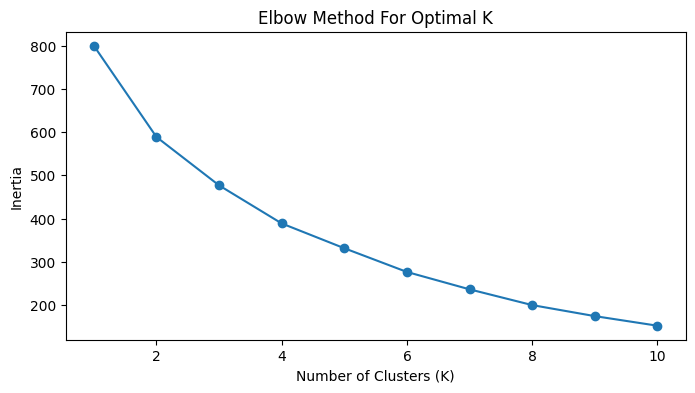

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal K")
plt.show()

K = 2: Silhouette Score = 0.252
K = 3: Silhouette Score = 0.260
K = 4: Silhouette Score = 0.298
K = 5: Silhouette Score = 0.304
K = 6: Silhouette Score = 0.331
K = 7: Silhouette Score = 0.357
K = 8: Silhouette Score = 0.388
K = 9: Silhouette Score = 0.403
K = 10: Silhouette Score = 0.421


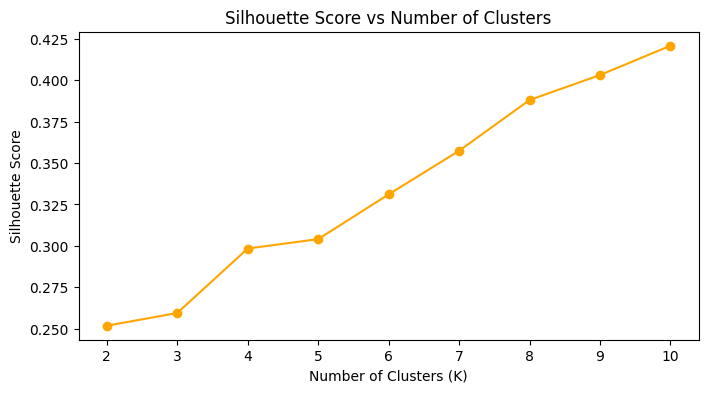

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)  # Silhouette score requires at least 2 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k}: Silhouette Score = {score:.3f}")

# Plot Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, marker="o", color="orange")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Separate your feature columns
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']

# 2. Fit the scaler on features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

# 3. Fit K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

# 4. Attach cluster labels back to the ORIGINAL dataframe
df['Cluster'] = cluster_labels

# 5. Inspect original values (Un-scaled)
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
summary['Customer Count'] = df['Cluster'].value_counts()

print(summary)

               Age  Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                                       
0        32.692308           86.538462               82.128205              39
1        36.482759           89.517241               18.000000              29
2        49.813953           49.232558               40.069767              43
3        24.907407           39.722222               61.203704              54
4        55.714286           53.685714               36.771429              35


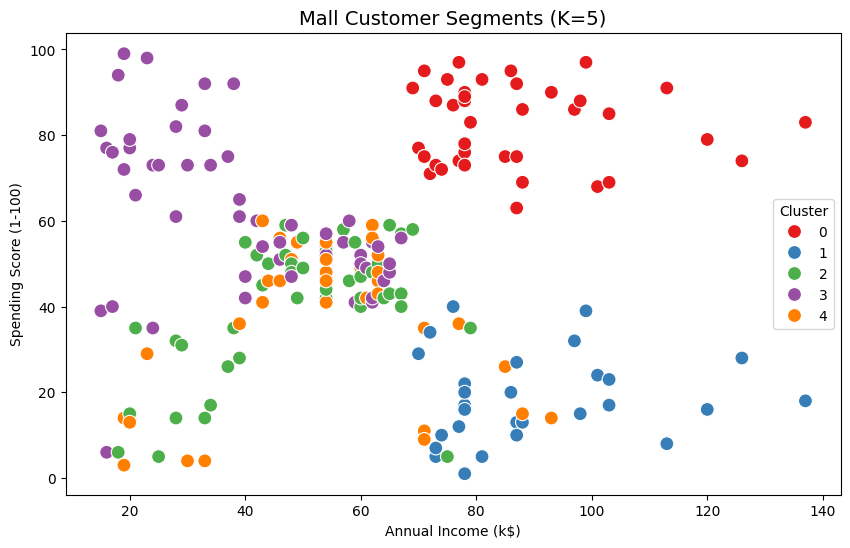

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100,
)

plt.title("Mall Customer Segments (K=5)", fontsize=14)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

In [ ]:
# 1. Install Gradio (run if not already installed in Colab)
# !pip install -q gradio

import gradio as gr
import pandas as pd


CLUSTER_PERSONAS = {
    0: {
        "name": "Sensible / Budget Shoppers",
        "action": "Send value bundle offers and discount coupons for essential items.",
    },
    1: {
        "name": "Careless / Impulse Spenders",
        "action": "Target with flashy trend notifications and low installment payment options.",
    },
    2: {
        "name": "Standard Shoppers",
        "action": "Include in general weekly email catalog and store updates.",
    },
    3: {
        "name": "Careful / High-Income Savers",
        "action": "Send premium brand value messaging and quality-focused product catalogs.",
    },
    4: {
        "name": "VIP / High-Value Customers",
        "action": "Provide VIP lounge access, early product drop invites, and personal shopper alerts.",
    },
}


def ui_predict_agent(customer_id, gender, age, income, score):
    """Wrapper function to format Gradio UI inputs and run inference."""
    customer_dict = {
        "CustomerID": customer_id if customer_id else "New Customer",
        "Gender": gender,
        "Age": age,
        "Annual Income (k$)": income,
        "Spending Score (1-100)": score,
    }

    # Format into DataFrame with training column structure
    raw_df = pd.DataFrame(
        [
            {
                "Age": customer_dict["Age"],
                "Annual Income (k$)": customer_dict["Annual Income (k$)"],
                "Spending Score (1-100)": customer_dict[
                    "Spending Score (1-100)"
                ],
                "Gender_Male": 1 if customer_dict["Gender"] == "Male" else 0,
            }
        ]
    )

    # Scale and predict
    scaled_df = scaler.transform(raw_df)
    cluster_id = int(kmeans.predict(scaled_df)[0])
    persona = CLUSTER_PERSONAS[cluster_id]

    # Formatted UI Output
    output_text = (
        f"👤 Customer ID: {customer_dict['CustomerID']}\n"
        f"📊 Assigned Cluster: Cluster {cluster_id}\n"
        f"🏷️ Persona: {persona['name']}\n\n"
        f"✉️ Recommended Marketing Action:\n{persona['action']}"
    )

    return output_text


# Build Gradio Web Interface
interface = gr.Interface(
    fn=ui_predict_agent,
    inputs=[
        gr.Textbox(
            label="Customer ID / Name",
            placeholder="e.g., CUST-101",
            value="CUST-101",
        ),
        gr.Radio(["Female", "Male"], label="Gender", value="Female"),
        gr.Slider(
            minimum=18, maximum=70, step=1, value=30, label="Age (Years)"
        ),
        gr.Slider(
            minimum=15,
            maximum=140,
            step=1,
            value=70,
            label="Annual Income (k$)",
        ),
        gr.Slider(
            minimum=1,
            maximum=100,
            step=1,
            value=75,
            label="Spending Score (1-100)",
        ),
    ],
    outputs=gr.Textbox(label="Agent Decision Analysis", lines=6),
    title="🤖 Mall Customer Segmentation Agent",
    description="Adjust customer demographics and behavior metrics to get real-time persona classification and targeted action strategies.",
)

# Launch live interface (set share=True for a public URL)
interface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8dab5c394a71c19f91.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8dab5c394a71c19f91.gradio.live
